In [126]:
import alphapepttools as apt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mudata as md
import muon
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2, venn3
from sklearn.preprocessing import MultiLabelBinarizer

In [127]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

In [128]:
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}
dark_palette = {"proteins": "#4B9384", "rna": "#468FF5", "methylation": "#682381"}

In [129]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/sit

In [130]:
# Shared color scheme for the omics modalities, reused across loading and enrichment plots
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}


def plot_modality_loadings(
    data: pd.DataFrame,
    *,
    score: str,
    feature: str,
    palette: dict,
    modality_column: str = "modality",
    xlabel: str = "Score",
    ax: plt.Axes | None = None,
    fontsize: int = 5,
) -> plt.Axes:
    """Horizontal bar plot of per-feature scores, colored by omics modality.

    Used to display either MOFA+ factor loadings or gene set enrichment scores. Each
    bar corresponds to a single feature (a gene or a pathway) and is colored by the
    modality it originates from.

    Parameters
    ----------
    data
        Long-format dataframe with one row per feature.
    score
        Column holding the numeric value drawn as bar length (x-axis).
    feature
        Column holding the feature labels shown on the y-axis.
    palette
        Mapping of modality name to color.
    modality_column
        Column holding the modality of each feature.
    xlabel
        Label of the x-axis.
    ax
        Axes to draw on. If `None`, a new figure and axes are created.

    Notes
    -----
    Feature labels that occur more than once in `data` (e.g. a pathway or gene shared
    across modalities) are rendered in bold to highlight cross-modal agreement.
    """
    data = data.sort_values(by=score)
    colors = data[modality_column].map(palette)

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 8))

    ax.barh(range(len(data)), data[score], color=colors)
    ax.set_yticks(range(len(data)))
    labels = ax.set_yticklabels(data[feature], fontsize=fontsize)

    # Highlight features that occur in more than one row (e.g. shared across modalities)
    feature_counts = data[feature].value_counts()
    for label, name in zip(labels, data[feature], strict=True):
        if feature_counts[name] > 1:
            label.set_fontweight("bold")
    ax.axvline(0, color="black", linewidth=0.8)  # zero reference line
    ax.set_xlabel(xlabel, labelpad=0)

    # Legend mapping each color back to its modality
    handles = [
        mpatches.Patch(color=color, label=modality)
        for modality, color in palette.items()
    ]
    ax.legend(
        handles=handles, title="Modality", bbox_to_anchor=(1.01, 1), loc="upper left"
    )

    ax.spines[["top", "right"]].set_visible(False)
    return ax

## Parameters

In [161]:
OVERLAP_THRESHOLD = 0.5

# Parameters
FACTOR = 2
SIGNIFICANCE_THRESHOLD = 1e-3

In [132]:
pathway_database = "go_biological_process"
gsea_results = pd.read_csv(
    f"../data/results/gsea-results.{pathway_database}.tsv", sep="\t", index_col=0
)
gsea_results

,factor,pathway,score,pval_adj,modality
0,0,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,0.930944,1.000000,methylation
1,1,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,-1.052830,0.914358,methylation
2,2,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,0.732471,1.000000,methylation
3,3,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,0.977130,0.994548,methylation
4,4,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,-1.101323,0.838788,methylation
...,...,...,...,...,...
166045,20,GOBP_ZYMOGEN_ACTIVATION,1.388325,0.499179,rna
166046,21,GOBP_ZYMOGEN_ACTIVATION,0.816261,0.989686,rna
166047,22,GOBP_ZYMOGEN_ACTIVATION,-1.462598,0.426492,rna
166048,23,GOBP_ZYMOGEN_ACTIVATION,0.651726,0.995252,rna


In [133]:
# methylation is anticorrelated
gsea_results["score"] = gsea_results.apply(lambda row: -row["score"] if row["modality"] in ["methylation"] else row["score"], axis=1)

## Define non-redundant set of genesets

In [134]:
network = pd.read_csv(
    f"../data/raw/{pathway_database}.network.tsv", sep="\t", index_col=0
)
network

,target,collection,source
15,A1BG,go_biological_process,GOBP_IMMUNE_RESPONSE_REGULATING_SIGNALING_PATHWAY
53,A1BG,go_biological_process,GOBP_REGULATION_OF_IMMUNE_SYSTEM_PROCESS
54,A1BG,go_biological_process,GOBP_REGULATION_OF_IMMUNE_RESPONSE
85,A1CF,go_biological_process,GOBP_NUCLEAR_TRANSCRIBED_MRNA_CATABOLIC_PROCESS
96,A1CF,go_biological_process,GOBP_INTRACELLULAR_MRNA_LOCALIZATION
...,...,...,...
5895303,ZZZ3,go_biological_process,GOBP_REGULATION_OF_CELL_CYCLE
5895313,ZZZ3,go_biological_process,GOBP_EMBRYO_DEVELOPMENT
5895380,ZZZ3,go_biological_process,GOBP_REGULATION_OF_MULTICELLULAR_ORGANISMAL_DE...
5895390,ZZZ3,go_biological_process,GOBP_CHROMATIN_ORGANIZATION


In [135]:
grouped_networks = network.groupby("source").agg({"target": lambda x: set(x)})
grouped_networks

# Binary pathway x gene membership matrix from the gene sets (sparse keeps memory low for ~1300 pathways)
mlb = MultiLabelBinarizer(sparse_output=True)
membership = mlb.fit_transform(grouped_networks["target"])

In [136]:
# Pairwise overlap coefficient |A n B| / min(|A|, |B|): a small set fully nested in a larger one scores 1.0,
# which Jaccard would miss because the large union shrinks the ratio.
intersection = (membership @ membership.T).toarray()
sizes = np.asarray(membership.sum(axis=1)).ravel()
overlap = intersection / np.minimum(sizes[:, None], sizes[None, :])
overlap

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(7580, 7580))

In [137]:
# Fraction of off-diagonal pairs exceeding the threshold (diagonal is self-overlap = 1.0)
off_diagonal = ~np.eye(len(overlap), dtype=bool)
(overlap[off_diagonal] > OVERLAP_THRESHOLD).mean()

np.float64(0.08355081966870687)

## Subset

In [138]:
significant_pathways = (
    gsea_results.loc[(gsea_results["pval_adj"] <= SIGNIFICANCE_THRESHOLD) & (gsea_results["score"] > 0)]
    .groupby("factor").apply(lambda df: df.pivot_table(index="factor", columns="modality", values="pathway", aggfunc=list).reset_index(level=0))
    .reset_index(drop=True)


)

significant_pathways

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_6250/3388081252.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("factor").apply(lambda df: df.pivot_table(index="factor", columns="modality", values="pathway", aggfunc=list).reset_index(level=0))


modality,factor,methylation,proteins,rna
0,0,"[GOBP_APOPTOTIC_PROCESS, GOBP_CARBOHYDRATE_PHO...","[GOBP_ACTIN_FILAMENT_BASED_MOVEMENT, GOBP_ACTI...","[GOBP_ACTIN_FILAMENT_BASED_PROCESS, GOBP_ACTIN..."
1,1,"[GOBP_CARBOHYDRATE_METABOLIC_PROCESS, GOBP_DEV...","[GOBP_ALCOHOL_METABOLIC_PROCESS, GOBP_ALPHA_AM...","[GOBP_AMIDE_BIOSYNTHETIC_PROCESS, GOBP_CYTOSKE..."
2,2,[GOBP_CO_TRANSCRIPTIONAL_RNA_3_END_PROCESSING_...,"[GOBP_ACTIN_FILAMENT_BASED_PROCESS, GOBP_ANATO...","[GOBP_APOPTOTIC_SIGNALING_PATHWAY, GOBP_APPEND..."
3,3,[GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPEC...,"[GOBP_ALPHA_AMINO_ACID_BIOSYNTHETIC_PROCESS, G...","[GOBP_AEROBIC_RESPIRATION, GOBP_ALCOHOL_METABO..."
4,4,"[GOBP_ADULT_BEHAVIOR, GOBP_ADULT_LOCOMOTORY_BE...","[GOBP_CELLULAR_RESPONSE_TO_STRESS, GOBP_CHROMO...","[GOBP_CELL_DIFFERENTIATION_IN_HINDBRAIN, GOBP_..."
5,5,[GOBP_ADAPTIVE_IMMUNE_RESPONSE_BASED_ON_SOMATI...,"[GOBP_BLASTOCYST_DEVELOPMENT, GOBP_CELLULAR_RE...",NaN
6,6,"[GOBP_BLOOD_VESSEL_ENDOTHELIAL_CELL_MIGRATION,...","[GOBP_ACTIN_FILAMENT_BASED_PROCESS, GOBP_ACTIN...","[GOBP_ACTIN_FILAMENT_BASED_PROCESS, GOBP_ACTIN..."
7,7,"[GOBP_AUTOPHAGOSOME_MEMBRANE_DOCKING, GOBP_CEN...","[GOBP_ACYL_COA_METABOLIC_PROCESS, GOBP_AEROBIC...","[GOBP_ACTIVATION_OF_IMMUNE_RESPONSE, GOBP_ADAP..."
8,8,"[GOBP_FORMATE_METABOLIC_PROCESS, GOBP_GLUTAMAT...","[GOBP_ATP_BIOSYNTHETIC_PROCESS, GOBP_CHROMOSOM...","[GOBP_BLOOD_VESSEL_MORPHOGENESIS, GOBP_CELLULA..."
9,9,"[GOBP_CELLULAR_COMPONENT_DISASSEMBLY, GOBP_CEL...","[GOBP_CHROMATIN_LOOPING, GOBP_CHROMATIN_ORGANI...","[GOBP_EPIDERMAL_CELL_DIFFERENTIATION, GOBP_KER..."


In [162]:
for _, r in significant_pathways.sort_values(by="factor").iterrows():

    row = r.to_dict()
    protein, rna, methylation = row["proteins"], row["rna"], row["methylation"]

    if isinstance(protein, float):
        protein = []
    
    if isinstance(rna, float):
        rna = []    
    if isinstance(methylation, float):
        methylation = []


    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
    venn3((set(protein), set(rna), set(methylation)), set_labels=None, set_colors=dark_palette.values())

    fig.savefig(f"../data/plots/gsea-{pathway_database}.factor-{row['factor']}-overlap.png", transparent=True, dpi=600)

    plt.show()

    if row["factor"] > 5: break

KeyError: 'proteins'

In [165]:
significant_pathways = gsea_results.loc[
    # (gsea_results["factor"] == FACTOR) & 
    (gsea_results["pval_adj"] <= SIGNIFICANCE_THRESHOLD)
].sort_values(by="score")

significant_pathways

,factor,pathway,score,pval_adj,modality
135750,0,GOBP_RNA_PROCESSING,-3.551036,0.0,proteins
52875,0,GOBP_MRNA_PROCESSING,-3.451286,0.0,proteins
17075,0,GOBP_CHROMATIN_ORGANIZATION,-3.390005,0.0,proteins
17275,0,GOBP_CHROMOSOME_SEGREGATION,-3.365401,0.0,proteins
23050,0,GOBP_DNA_REPLICATION,-3.360409,0.0,proteins
...,...,...,...,...,...
135794,19,GOBP_RNA_SPLICING,2.685622,0.0,proteins
50028,3,GOBP_MITOCHONDRIAL_GENE_EXPRESSION,2.781703,0.0,proteins
136128,3,GOBP_RRNA_PROCESSING,2.824572,0.0,proteins
50428,3,GOBP_MITOCHONDRIAL_TRANSLATION,2.834489,0.0,proteins


In [166]:
# Gene-set overlap is modality-independent (same pathway -> same genes), but redundancy is collapsed
# separately per modality so each modality's significant pathways drive its own selection.
position = {pathway: i for i, pathway in enumerate(grouped_networks.index)}
mapped = set(grouped_networks.index)

kept_rows = []
for modality, group in significant_pathways.groupby("modality"):
    pathways = group["pathway"].unique()

    # Greedy collapse, largest-first: walk pathways from biggest gene set to smallest and keep one only
    # if it does not overlap an already-kept (larger) pathway beyond the threshold. This keeps the broad
    # parent term of each redundant cluster and drops its more specific members. Pathways without gene
    # mappings have no size, cannot be assessed, and are retained as-is.
    # ordered = sorted(
    #     (p for p in pathways if p in mapped),
    #     key=lambda p: sizes[position[p]],
    #     reverse=False,
    # )

    strength = group.groupby("pathway")["score"].apply(lambda s: s.abs().max())
    ordered = sorted(strength.index, key=lambda p: strength[p], reverse=True)

    kept = [p for p in pathways if p not in mapped]
    kept_idx = []
    for pathway in ordered:
        i = position[pathway]
        if all(overlap[i, j] <= OVERLAP_THRESHOLD for j in kept_idx):
            kept.append(pathway)
            kept_idx.append(i)

    kept_rows.append(group[group["pathway"].isin(set(kept))])
    print(f"{modality}: {len(pathways)} -> {len(kept)} pathways")

non_redundant = pd.concat(kept_rows)
non_redundant

methylation: 682 -> 241 pathways
proteins: 2586 -> 452 pathways
rna: 1711 -> 398 pathways


,factor,pathway,score,pval_adj,modality
142783,8,GOBP_RIBOSOME_DISASSEMBLY,-2.159671,0.0,methylation
151101,1,GOBP_THYMIC_T_CELL_SELECTION,-2.073102,0.0,methylation
100351,1,GOBP_POSITIVE_REGULATION_OF_T_CELL_PROLIFERATION,-2.002848,0.0,methylation
110876,1,GOBP_REGULATION_OF_ANTIGEN_RECEPTOR_MEDIATED_S...,-1.983537,0.0,methylation
151801,1,GOBP_TORC2_SIGNALING,-1.947612,0.0,methylation
...,...,...,...,...,...
68100,0,GOBP_NEGATIVE_REGULATION_OF_IMMUNE_EFFECTOR_PR...,2.192127,0.0,rna
4475,0,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,2.211277,0.0,rna
46502,2,GOBP_KERATINIZATION,2.219249,0.0,rna
29103,3,GOBP_ENDOPLASMIC_RETICULUM_TO_GOLGI_VESICLE_ME...,2.222015,0.0,rna


In [170]:
r

modality
methylation    [GOBP_SENSORY_PERCEPTION_OF_SMELL, GOBP_SKIN_E...
proteins       [GOBP_RNA_PROCESSING, GOBP_CHROMATIN_ORGANIZAT...
rna            [GOBP_CHROMOSOME_SEGREGATION, GOBP_DNA_REPLICA...
Name: 0, dtype: object

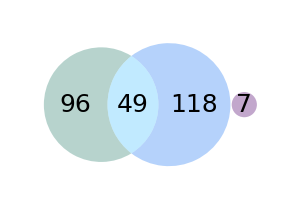

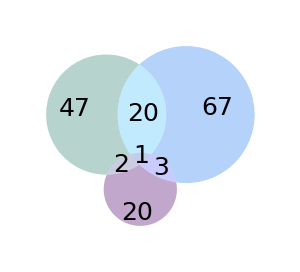

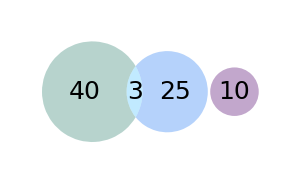

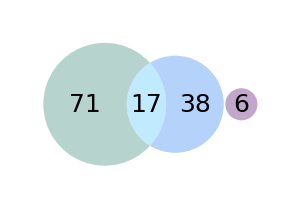

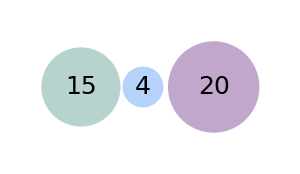

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


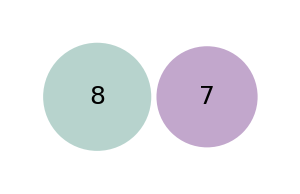

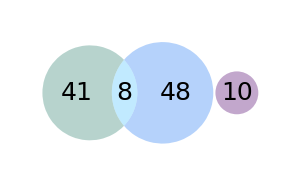

In [171]:
for factor, r in non_redundant.pivot_table(index="factor", columns="modality", values="pathway", aggfunc=lambda x: x).sort_values(by="factor").iterrows():

    row = r.to_dict()
    protein, rna, methylation = row["proteins"], row["rna"], row["methylation"]

    if isinstance(protein, float):
        protein = []
    
    if isinstance(rna, float):
        rna = []    
    if isinstance(methylation, float):
        methylation = []


    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
    venn3((set(protein), set(rna), set(methylation)), set_labels=None, set_colors=dark_palette.values())

    # fig.savefig(f"../data/plots/gsea-{pathway_database}.factor-{row['factor']}-overlap.png", transparent=True, dpi=600)

    plt.show()

    if factor > 5: break

In [150]:
# fig, ax = plt.subplots(figsize=(4, 20))

# plot_modality_loadings(
#     non_redundant,
#     score="score",
#     feature="pathway",
#     palette=palette,
#     xlabel="Enrichment score",
#     ax=ax,
# )

# plt.tight_layout()
# plt.show()

In [151]:
non_redundant["pathway_simplified"] = non_redundant["pathway"].str.replace("HALLMARK_", "").str.replace("_", " ")

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_6250/1281375643.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_6250/1281375643.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax[0].legend()
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_6250/1281375643.py:18: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(f"../data/plots/gsea_{pathway_database}_factor-{FACTOR}.png", transparent=True, dpi=600, bbox_inches="tight")
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_6250/1281375643.py:18: UserWarning: constrained_lay

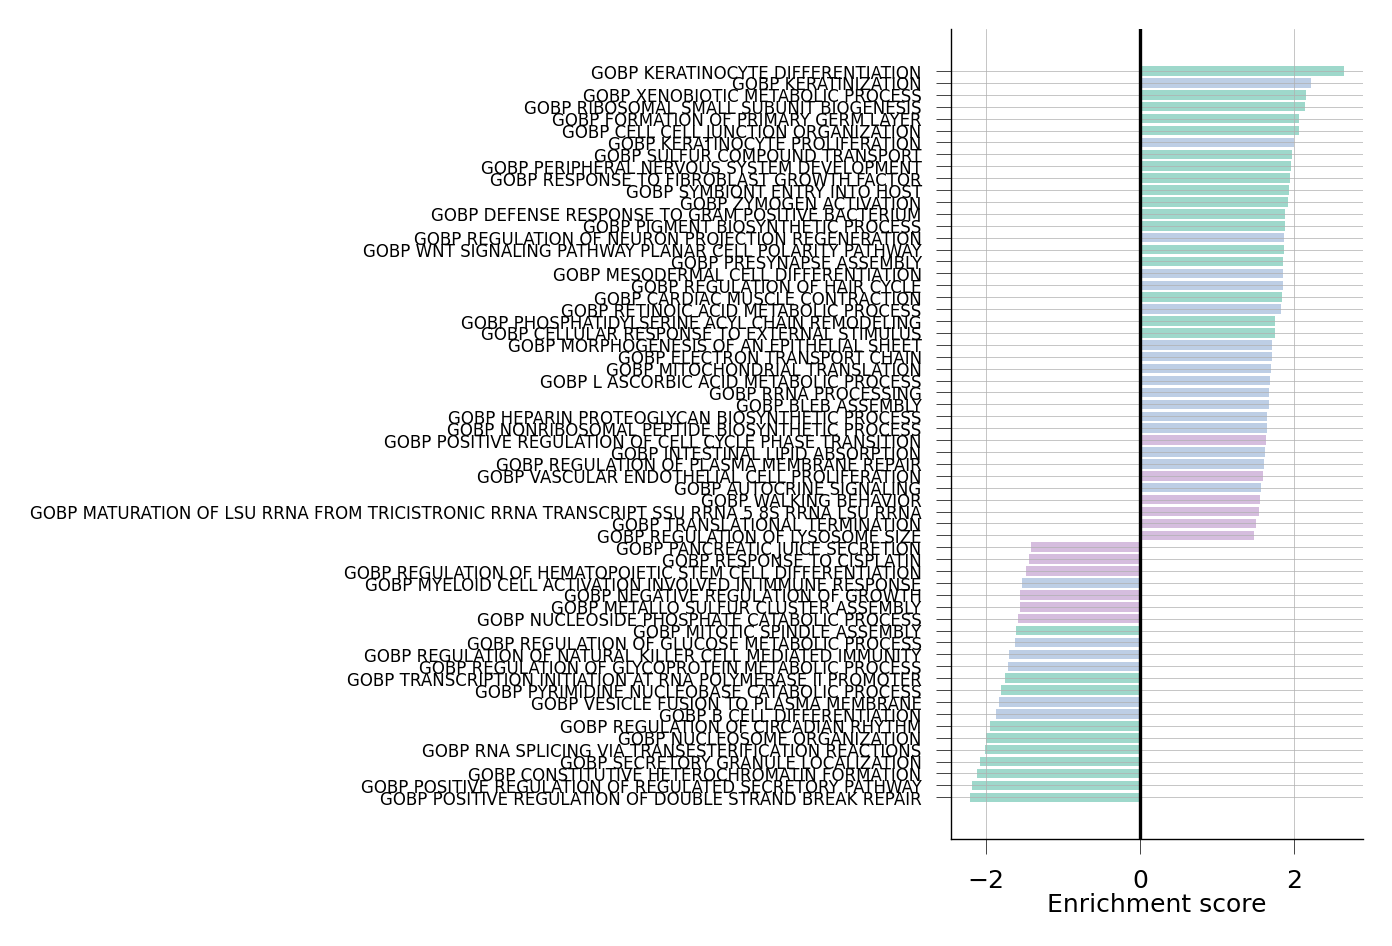

In [152]:
fig, ax = apt.pl.create_figure(figsize=("0.5", "1"))

plot_modality_loadings(
    non_redundant,
    score="score",
    feature="pathway_simplified",
    palette=palette,
    xlabel="Enrichment score",
    ax=ax[0],
    # fontsize=apt.pl.defaults.PlotSettings().to_dict().get("font_sizes").get("small")
)
ax[0].legend()
legend = ax[0].legend()
handles, labels = ax[0].get_legend_handles_labels()
legend.remove()

ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=4)
fig.savefig(f"../data/plots/gsea_{pathway_database}_factor-{FACTOR}.png", transparent=True, dpi=600, bbox_inches="tight")

plt.show()

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_6250/114622858.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


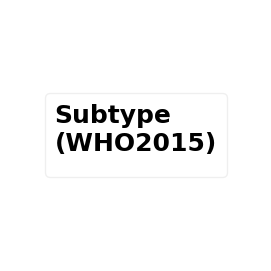

In [153]:
handles = [mpatches.Patch(facecolor=color) for color in palette.values()]
fontsize=6


fig, axm = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
ax = axm.next()

ax.legend(
    handles,
    labels,
    loc="center",
    title="Subtype\n(WHO2015)",
    title_fontproperties={"weight": "bold", "size": fontsize},
    alignment="left",
    fontsize=fontsize,
    facecolor="#ffffff",
    framealpha=0.3,
    # edgecolor=",
    ncols=2,
    columnspacing=0.0,
    frameon=True,
    handletextpad=0.,
)
ax.set_axis_off()
plt.tight_layout()
fig.savefig("../data/plots/gsea.legend.png", bbox_inches="tight", dpi=600, transparent=True)
plt.show()